In [ ]:
# from cleaning_rules_continuous import cleaning_rules
import C_preprocessing_helpers as ph
from implementations import (
    mean_squared_error_gd,
    mean_squared_error_sgd,
    least_squares,
    ridge_regression,
    logistic_regression,
    reg_logistic_regression
)
from E_scoring_functions import f1, accuracy
import numpy as np
from A_loading_helpers import load_csv_data, save_numpy, load_numpy, create_csv_submission
import os
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Model experiments


## Functions

In [ ]:
y_train = load_numpy('y_train.npy')


Loaded NumPy array from: /content/y_train.npy | shape: (328135, 2)


In [ ]:
test_ids = load_numpy('test_ids.npy')

Loaded NumPy array from: /content/test_ids.npy | shape: (109379,)


#### Downsampling function

In [ ]:
def downsample(X_train, y_train, major_value=-1, num=2):
    np.random.seed(42)
    majority_idx = np.where(y_train[:, 1] == major_value)[0]
    minority_idx = np.where(y_train[:, 1] != major_value)[0]
    n_minority = len(minority_idx)
    n_majority = len(majority_idx)
    majority_downsample_idx = np.random.choice(majority_idx, size=int(n_minority*num), replace=False)
    balanced_idx = np.concatenate([minority_idx, majority_downsample_idx])
    np.random.shuffle(balanced_idx)

    X_train_down = X_train[balanced_idx]
    y_train_down = y_train[balanced_idx]
    return X_train_down, y_train_down

#### Train test split function

In [ ]:
import numpy as np

def train_test_split_np(*arrays, test_size=0.25, train_size=None, random_state=None, shuffle=True):
    """
    A NumPy-only implementation of sklearn's train_test_split.

    Parameters
    ----------
    *arrays : array-like
        One or more arrays to split (e.g., X, y).
    test_size : float or int, default=0.25
        If float, represents the proportion of the dataset to include in the test split.
        If int, represents the absolute number of test samples.
    train_size : float or int, optional
        If float, represents the proportion of the dataset to include in the train split.
        If int, represents the absolute number of train samples.
    random_state : int, optional
        Controls the shuffling for reproducibility.
    shuffle : bool, default=True
        Whether to shuffle the data before splitting.

    Returns
    -------
    Splits of input arrays in the order:
        X_train, X_test, y_train, y_test (for 2 input arrays)
    or generally:
        train/test splits for each array passed.
    """

    # Check that at least one array is provided
    if len(arrays) == 0:
        raise ValueError("At least one array required as input.")

    # Check that all arrays have the same first dimension
    n_samples = len(arrays[0])
    for arr in arrays:
        if len(arr) != n_samples:
            raise ValueError("All input arrays must have the same number of samples.")

    # Set random seed
    rng = np.random.default_rng(random_state)

    # Determine test size and train size
    if isinstance(test_size, float):
        n_test = int(np.ceil(n_samples * test_size))
    elif isinstance(test_size, int):
        n_test = test_size
    else:
        raise ValueError("test_size must be a float or int.")

    if train_size is None:
        n_train = n_samples - n_test
    elif isinstance(train_size, float):
        n_train = int(np.floor(n_samples * train_size))
    elif isinstance(train_size, int):
        n_train = train_size
    else:
        raise ValueError("train_size must be a float or int.")

    if n_train + n_test > n_samples:
        raise ValueError("The sum of train_size and test_size cannot exceed the number of samples.")

    # Generate shuffled indices
    indices = np.arange(n_samples)
    if shuffle:
        rng.shuffle(indices)

    # Split indices
    test_indices = indices[:n_test]
    train_indices = indices[n_test:n_test + n_train]

    # Split arrays
    result = []
    for arr in arrays:
        arr = np.asarray(arr)
        result.append(arr[train_indices])
        result.append(arr[test_indices])

    return tuple(result)


### Sigmoid


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#### Json creatign and updating function

In [ ]:
import json
import os
import numpy as np

def create_results_json(filepath, models):
    """
    Creates an empty results JSON file with the required structure.
    (Feature lists will be added dynamically later.)
    """
    if not os.path.exists(filepath):
        results = {
            "models": models,
            "feature_lists": [],
            "f1": {model: [] for model in models},
            "accuracy": {model: [] for model in models}
        }

        with open(filepath, 'w') as f:
            json.dump(results, f, indent=2)
        print(f"Created new results file: {filepath}")
    else:
        print(f"File already exists: {filepath}")


def update_results_json(filepath, feature_list_name, f1_dict, acc_dict):
    """
    Updates existing JSON file with new feature list name
    and its F1/Accuracy results.

    Each call adds one feature list and one new set of results per model.
    """
    # Load current results
    with open(filepath, 'r') as f:
        results = json.load(f)

    # Add the new feature list name
    results["feature_lists"].append(feature_list_name)

    # Update results for each model
    for model in results["models"]:
        f1_val = float(f1_dict.get(model, np.nan))
        acc_val = float(acc_dict.get(model, np.nan))
        results["f1"][model].append(f1_val)
        results["accuracy"][model].append(acc_val)

    # Save updated JSON
    with open(filepath, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Updated results with feature list: '{feature_list_name}'")


## Correlation filtration first dataset

In [ ]:
x_train_first = load_numpy('x_train_processed_corrfilter_first.npy')


Loaded NumPy array from: /content/x_train_processed_corrfilter_first.npy | shape: (328135, 493)


In [ ]:
X_train_first, X_val_first, y_train_first, y_val_first = train_test_split_np(x_train_first, y_train, test_size=0.3, random_state=42)


In [ ]:
X_train_first_down, y_train_first_down = downsample(X_train_first, y_train_first, major_value=-1, num=3)

In [ ]:
f1_dict = {}
accuracy_dict = {}

For regression functions we can use default targets {-1, 1}, for logistic regression as it involves sigmoid function we need to change negative class from -1 to 0.

In [ ]:
y_train_first_down_dif_target = y_train_first_down.copy()
y_val_first_dif_target = y_val_first.copy()
y_train_first_down_dif_target[y_train_first_down_dif_target[:, 1] == -1, 1] = 0
y_val_first_dif_target[y_val_first_dif_target[:, 1] == -1, 1] = 0

In [ ]:
y_train_first_down.shape


(81220, 2)

In [ ]:
# Linear regression with GD
# We want to make grid search for gamma parameter

gammas = [ 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
max_iterations = 100
initial_w_first = np.random.normal(size=(X_train_first_down.shape[1],1))
f1_first = []
accuracy_first = []

for gamma in tqdm(gammas):
    w, loss = mean_squared_error_gd(
        y=y_train_first_down,
        tx=X_train_first_down,
        initial_w=initial_w_first,
        max_iters=max_iterations,
        gamma=gamma)
    y_pred = np.sign(X_val_first @ w)
    # print(y_pred.shape)
    f1_first.append(f1(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    ))
    accuracy_first.append(accuracy(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    ))


 17%|█▋        | 1/6 [00:44<03:42, 44.55s/it]

(98441, 2)


 33%|███▎      | 2/6 [01:28<02:57, 44.34s/it]

(98441, 2)


 50%|█████     | 3/6 [02:13<02:12, 44.31s/it]

...

(98441, 2)


 83%|████████▎ | 5/6 [03:42<00:44, 44.49s/it]

(98441, 2)


100%|██████████| 6/6 [04:29<00:00, 44.98s/it]

(98441, 2)


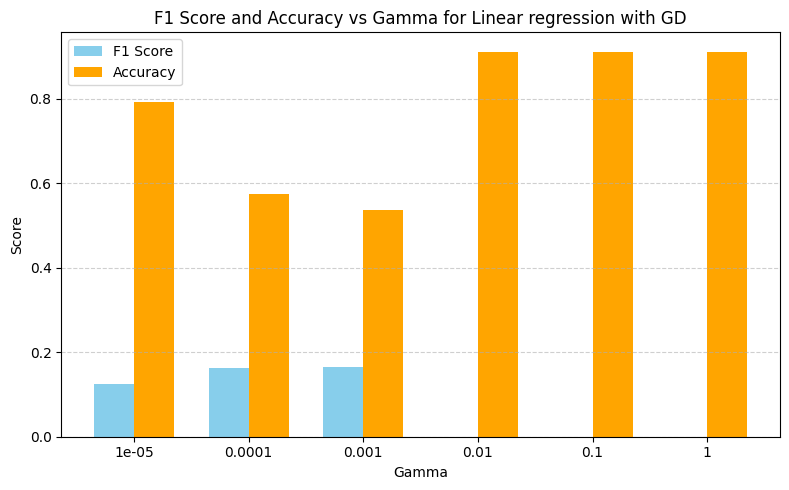

In [ ]:
x = np.arange(len(gammas))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_first, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, accuracy_first, width, label='Accuracy', color='orange')

# Labels and formatting
plt.xticks(x, [str(g) for g in gammas])
plt.xlabel('Gamma')
plt.ylabel('Score')
plt.title('F1 Score and Accuracy vs Gamma for Linear regression with GD')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
f1_dict['GD'] = f1_first[2]
accuracy_dict['GD'] = accuracy_first[2]

100%|██████████| 6/6 [00:02<00:00,  2.43it/s]


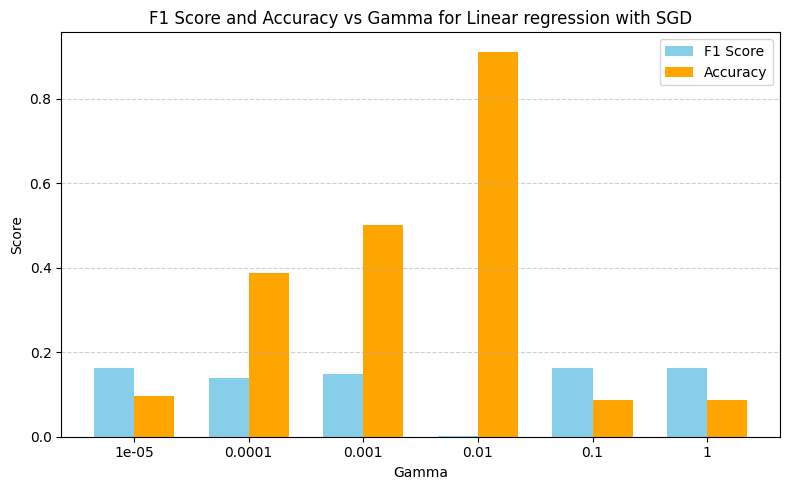

In [ ]:
# Linear regression with SGD
# We want to make grid search for gamma parameter

gammas = [ 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
max_iterations = 100
initial_w_first = np.random.normal(size=(X_train_first_down.shape[1],1))
f1_first = []
accuracy_first = []

for gamma in tqdm(gammas):
    w, loss = mean_squared_error_sgd(
        y=y_train_first_down,
        tx=X_train_first_down,
        initial_w=initial_w_first,
        max_iters=max_iterations,
        gamma=gamma)
    y_pred = np.sign(X_val_first @ w)
    f1_first.append(f1(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    ))
    accuracy_first.append(accuracy(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    ))

x = np.arange(len(gammas))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_first, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, accuracy_first, width, label='Accuracy', color='orange')

# Labels and formatting
plt.xticks(x, [str(g) for g in gammas])
plt.xlabel('Gamma')
plt.ylabel('Score')
plt.title('F1 Score and Accuracy vs Gamma for Linear regression with SGD')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [ ]:
f1_dict['SGD'] = f1_first[2]
accuracy_dict['SGD'] = accuracy_first[2]

In [ ]:
# Least squares
w, loss = least_squares(
        y=y_train_first_down,
        tx=X_train_first_down)
y_pred = np.sign(X_val_first @ w)
acc = accuracy(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_sc = f1(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
print(f"Accuracy:{acc}, F1:{f1_sc}")

f1_dict['LS'] = acc
accuracy_dict['LS'] = f1_sc

Accuracy:0.887120203980049, F1:0.41669291338582676


100%|██████████| 6/6 [00:09<00:00,  1.50s/it]


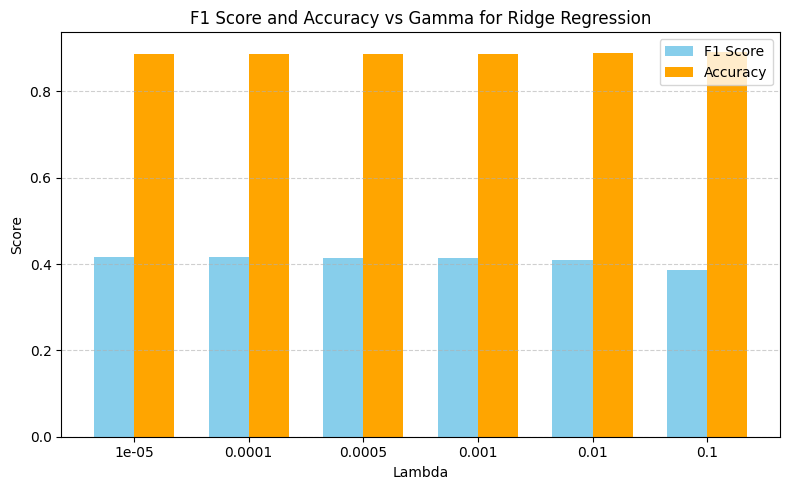

In [ ]:
# Ridge regression
lambdas = [ 1e-5, 1e-4, 5e-4, 1e-3, 1e-2, 1e-1]
f1_first = []
accuracy_first = []

for lambda_ in tqdm(lambdas):
    w, loss = ridge_regression(
        y=y_train_first_down,
        tx=X_train_first_down,
        lambda_=lambda_)
    y_pred = np.sign(X_val_first @ w)
    f1_first.append(f1(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    ))
    accuracy_first.append(accuracy(
        y_true=y_val_first[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    ))

x = np.arange(len(lambdas))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_first, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, accuracy_first, width, label='Accuracy', color='orange')

# Labels and formatting
plt.xticks(x, [str(l) for l in lambdas])
plt.xlabel('Lambda')
plt.ylabel('Score')
plt.title('F1 Score and Accuracy vs Gamma for Ridge Regression')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
f1_dict['RR'] = f1_first[1]
accuracy_dict['RR'] = accuracy_first[1]

100%|██████████| 6/6 [03:27<00:00, 34.56s/it]


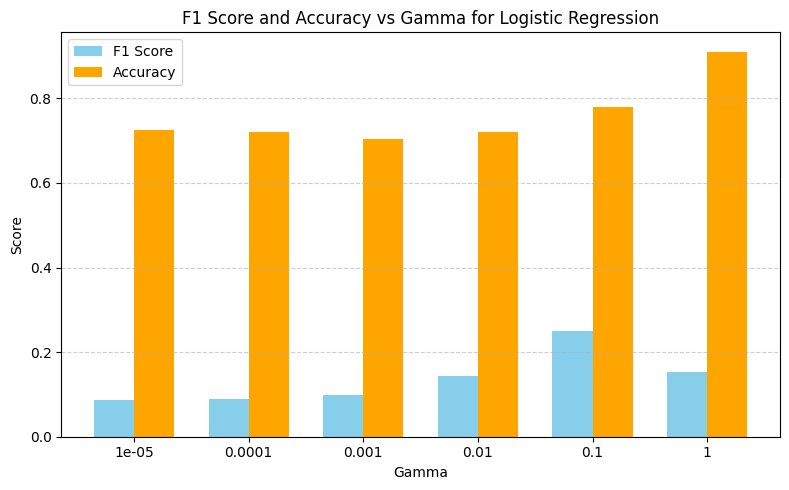

In [ ]:
## Logistic regression
# We want to make grid search for gamma parameter

gammas = [ 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
max_iterations = 100
initial_w_first = np.random.normal(size=(X_train_first_down.shape[1],1))
f1_first = []
accuracy_first = []

for gamma in tqdm(gammas):
    w, loss = logistic_regression(
        y=y_train_first_down_dif_target,
        tx=X_train_first_down,
        initial_w=initial_w_first,
        max_iters=max_iterations,
        gamma=gamma)
    y_pred = (sigmoid(X_val_first @ w)>= 0.5).astype(int)
    f1_first.append(f1(
        y_true=y_val_first_dif_target[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    ))
    accuracy_first.append(accuracy(
        y_true=y_val_first_dif_target[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    ))

x = np.arange(len(gammas))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_first, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, accuracy_first, width, label='Accuracy', color='orange')

# Labels and formatting
plt.xticks(x, [str(g) for g in gammas])
plt.xlabel('Gamma')
plt.ylabel('Score')
plt.title('F1 Score and Accuracy vs Gamma for Logistic Regression')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




In [ ]:
f1_dict['LR'] = f1_first[4]
accuracy_dict['LR'] = accuracy_first[4]

In [ ]:
## Regularized logistic regression
# We want to make grid search for gamma parameter and lambda parameter

gammas = [1e-2, 1e-1]
lambdas = [ 1e-5, 1e-4, 5e-4, 1e-3, 1e-2, 1e-1]
labels = []
max_iterations = 100
initial_w_first = np.random.normal(size=(X_train_first_down.shape[1],1))
f1_first = []
accuracy_first = []

for gamma in tqdm(gammas):
  for lambda_ in lambdas:
      labels.append(f"g={str(gamma)}"+ f"l={str(lambda_)}")
      w, loss = reg_logistic_regression(
          y=y_train_first_down_dif_target,
          tx=X_train_first_down,
          initial_w=initial_w_first,
          max_iters=max_iterations,
          gamma=gamma,
          lambda_=lambda_)
      y_pred = (sigmoid(X_val_first @ w)>= 0.5).astype(int)
      f1_first.append(f1(
          y_true=y_val_first_dif_target[:, 1],
          y_pred=y_pred[:, 1], labels=[0, 1]
      ))
      accuracy_first.append(accuracy(
          y_true=y_val_first_dif_target[:, 1],
          y_pred=y_pred[:, 1], labels=[0, 1]
      ))






100%|██████████| 2/2 [06:41<00:00, 200.84s/it]


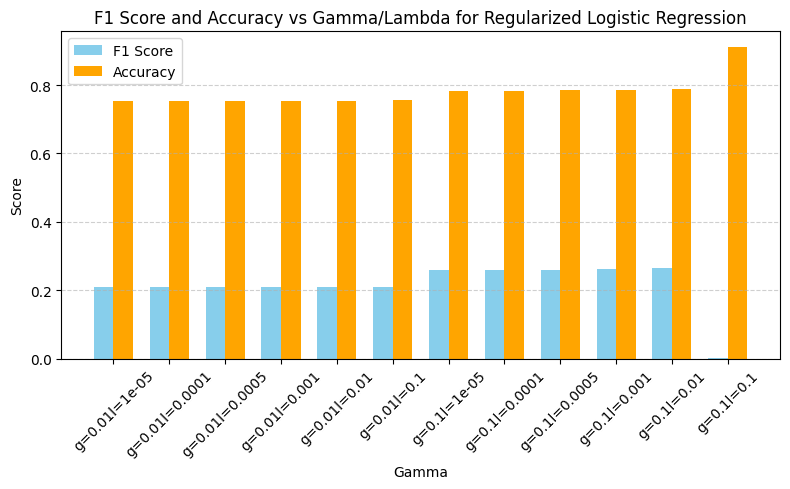

In [ ]:
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, f1_first, width, label='F1 Score', color='skyblue')
plt.bar(x + width/2, accuracy_first, width, label='Accuracy', color='orange')

# Labels and formatting
plt.xticks(x, [l for l in labels],rotation=45)
plt.xlabel('Gamma')
plt.ylabel('Score')
plt.title('F1 Score and Accuracy vs Gamma/Lambda for Regularized Logistic Regression')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
f1_dict['RLR'] = f1_first[-1]
accuracy_dict['RLR'] = accuracy_first[-1]

In [ ]:
create_results_json(filepath='/content/results.json',
                    models = list(f1_dict.keys()))
update_results_json(filepath='/content/results.json',
                    feature_list_name= "First",
                    f1_dict=f1_dict,
                    acc_dict=accuracy_dict
                    )

Created new results file: /content/results.json
Updated results with feature list: 'First'


## Correlation filtration: Nothing

With this features list and with later feature sets optimized paramters from the first experiment were used

In [ ]:
x_train_noth = load_numpy('x_train_processed_corrfilter_nothing.npy')
X_train_noth, X_val_noth, y_train_noth, y_val_noth = train_test_split_np(x_train_noth, y_train, test_size=0.3, random_state=42)
X_train_noth_down, y_train_noth_down = downsample(X_train_noth, y_train_noth, major_value=-1, num=3)

Loaded NumPy array from: /content/x_train_processed_corrfilter_nothing.npy | shape: (328135, 555)


In [ ]:
y_train_noth_down_dif_target = y_train_noth_down.copy()
y_val_noth_dif_target = y_val_noth.copy()
y_train_noth_down_dif_target[y_train_noth_down_dif_target[:, 1] == -1, 1] = 0
y_val_noth_dif_target[y_val_noth_dif_target[:, 1] == -1, 1] = 0

In [ ]:
f1_dict_noth = {}
acc_fict_noth = {}

In [ ]:
# Linear regression with GD

gamma = 1e-3
max_iterations = 100
initial_w_noth = np.random.normal(size=(X_train_noth_down.shape[1],1))

w, loss = mean_squared_error_gd(
        y=y_train_noth_down,
        tx=X_train_noth_down,
        initial_w=initial_w_noth,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = np.sign(X_val_noth @ w)

f1_noth = f1(
        y_true=y_val_noth,
        y_pred=y_pred, labels=[-1, 1]
    )
accuracy_noth = accuracy(
        y_true=y_val_noth,
        y_pred=y_pred, labels=[-1, 1]
    )

print(f"Linear Regression with GD, gamma = {gamma}, \n Accuracy:{accuracy_noth}, F1:{f1_noth}")
f1_dict_noth["GD"]=f1_noth
acc_fict_noth["GD"]=accuracy_noth

Linear Regression with GD, gamma = 0.001, 
 Accuracy:0.2773082353897258, F1:0.14101835707148877


In [ ]:
# Linear regression with SGD

gamma = 1e-3
max_iterations = 100
initial_w_noth = np.random.normal(size=(X_train_noth_down.shape[1],1))

w, loss = mean_squared_error_sgd(
        y=y_train_noth_down,
        tx=X_train_noth_down,
        initial_w=initial_w_noth,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = np.sign(X_val_noth @ w)

f1_noth = f1(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
accuracy_noth = accuracy(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Linear Regression with SGD, gamma = {gamma}, \n Accuracy:{accuracy_noth}, F1:{f1_noth}")
f1_dict_noth["SGD"]=f1_noth
acc_fict_noth["SGD"]=accuracy_noth

Linear Regression with SGD, gamma = 0.001, 
 Accuracy:0.1821954267022887, F1:0.15283174697734872


In [ ]:
# Least squares
w, loss = least_squares(
        y=y_train_noth_down,
        tx=X_train_noth_down)
y_pred = np.sign(X_val_noth @ w)
accuracy_noth = accuracy(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_noth = f1(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Least Squeares regression \n Accuracy:{accuracy_noth}, F1:{f1_noth}")
f1_dict_noth["LS"]=f1_noth
acc_fict_noth["LS"]=accuracy_noth

Least Squeares regression 
 Accuracy:0.4435753395434829, F1:0.42153493699885447


In [ ]:
# Ridge regression
lambda_= 1e-4
w, loss = ridge_regression(
        y=y_train_noth_down,
        tx=X_train_noth_down,
        lambda_=lambda_)
y_pred = np.sign(X_val_noth @ w)
accuracy_noth = accuracy(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_noth = f1(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
print(f"Ridge Regression with lambda={lambda_} \n Accuracy:{accuracy_noth}, F1:{f1_noth}")
f1_dict_noth["RR"]=f1_noth
acc_fict_noth["RR"]=accuracy_noth

Ridge Regression with lambda=0.0001 
 Accuracy:0.44376326936947, F1:0.41919748229740367


In [ ]:
## Logistic regression

gamma =  1e-1
max_iterations = 100
initial_w_noth = np.random.normal(size=(X_train_noth_down.shape[1],1))

w, loss = logistic_regression(
        y=y_train_noth_down_dif_target,
        tx=X_train_noth_down,
        initial_w=initial_w_noth,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = (sigmoid(X_val_noth @ w)>= 0.5).astype(int)
accuracy_noth = accuracy(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
f1_noth = f1(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
print(f"Logistic Regression with gamma={gamma} \n Accuracy:{accuracy_noth}, F1:{f1_noth}")
f1_dict_noth["LR"]=f1_noth
acc_fict_noth["LR"]=accuracy_noth



Logistic Regression with gamma=0.1 
 Accuracy:0.018686319724505032, F1:0.5957894736842105


In [ ]:
## Regularized logistic regression

gamma = 1e-1
lambda_ = 1e-2
max_iterations = 100
initial_w_noth = np.random.normal(size=(X_train_noth_down.shape[1],1))

w, loss = reg_logistic_regression(
          y=y_train_noth_down_dif_target,
          tx=X_train_noth_down,
          initial_w=initial_w_noth,
          max_iters=max_iterations,
          gamma=gamma,
          lambda_=lambda_)
y_pred = (sigmoid(X_val_noth @ w)>= 0.5).astype(int)

accuracy_noth = accuracy(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
f1_noth = f1(
        y_true=y_val_noth[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
print(f"Regularized Logistic Regression \n with gamma={gamma} and lambda={lambda_} \n Accuracy:{accuracy_noth}, F1:{f1_noth}")
f1_dict_noth["RLR"]=f1_noth
acc_fict_noth["RLR"]=accuracy_noth


Regularized Logistic Regression 
 with gamma=0.1 and lambda=0.01 
 Accuracy:0.01972755254416351, F1:0.6187176423735563


In [ ]:
update_results_json(filepath='/content/results.json',
                    feature_list_name= "Nothing",
                    f1_dict=f1_dict_noth,
                    acc_dict=acc_fict_noth
                    )

Updated results with feature list: 'Nothing'


## Correlation filtration: var

In [ ]:
x_train_var = load_numpy('x_train_processed_corrfilter_var.npy')
X_train_var, X_val_var, y_train_var, y_val_var = train_test_split_np(x_train_var, y_train, test_size=0.3, random_state=42)
X_train_var_down, y_train_var_down = downsample(X_train_var, y_train_var, major_value=-1, num=3)

ValueError: cannot reshape array of size 144310256 into shape (328135,489)

In [ ]:
y_train_var_down_dif_target = y_train_var_down.copy()
y_val_var_dif_target = y_val_var.copy()
y_train_var_down_dif_target[y_train_var_down_dif_target[:, 1] == -1, 1] = 0
y_val_var_dif_target[y_val_var_dif_target[:, 1] == -1, 1] = 0

In [ ]:
f1_dict_var = {}
acc_fict_var = {}

In [ ]:
# Linear regression with GD

gamma = 1e-3
max_iterations = 100
initial_w_var = np.random.normal(size=(X_train_var_down.shape[1],1))

w, loss = mean_squared_error_gd(
        y=y_train_var_down,
        tx=X_train_var_down,
        initial_w=initial_w_var,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = np.sign(X_val_var @ w)

f1_var = f1(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
accuracy_var = accuracy(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Linear Regression with GD, gamma = {gamma}, \n Accuracy:{accuracy_var}, F1:{f1_var}")
f1_dict_var["GD"]=f1_var
acc_fict_var["GD"]=accuracy_var

Linear Regression with GD, gamma = 0.001, 
 Accuracy:0.25664611290011274, F1:0.14943814240826542


In [ ]:
# Linear regression with SGD

gamma = 1e-3
max_iterations = 100
initial_w_var = np.random.normal(size=(X_train_var_down.shape[1],1))

w, loss = mean_squared_error_sgd(
        y=y_train_var_down,
        tx=X_train_var_down,
        initial_w=initial_w_var,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = np.sign(X_val_var @ w)

f1_var = f1(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
accuracy_var = accuracy(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Linear Regression with SGD, gamma = {gamma}, \n Accuracy:{accuracy_var}, F1:{f1_var}")
f1_dict_var["SGD"]=f1_var
acc_fict_var["SGD"]=accuracy_var

Linear Regression with SGD, gamma = 0.001, 
 Accuracy:0.30373523227110655, F1:0.16021210935802147


In [ ]:
# Least squares
w, loss = least_squares(
        y=y_train_var_down,
        tx=X_train_var_down)
y_pred = np.sign(X_val_var @ w)
accuracy_var = accuracy(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_var = f1(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Least Squeares regression \n Accuracy:{accuracy_var}, F1:{f1_var}")
f1_dict_var["LS"]=f1_var
acc_fict_var["LS"]=accuracy_var

Least Squeares regression 
 Accuracy:0.4432604301053423, F1:0.41421979865771813


In [ ]:
# Ridge regression
lambda_= 1e-4
w, loss = ridge_regression(
        y=y_train_var_down,
        tx=X_train_var_down,
        lambda_=lambda_)
y_pred = np.sign(X_val_var @ w)
accuracy_var = accuracy(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_var = f1(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
print(f"Ridge Regression with lambda={lambda_} \n Accuracy:{accuracy_var}, F1:{f1_var}")
f1_dict_var["RR"]=f1_var
acc_fict_var["RR"]=accuracy_var

Ridge Regression with lambda=0.0001 
 Accuracy:0.44337725134852346, F1:0.4145355248647797


In [ ]:
## Logistic regression

gamma =  1e-2
max_iterations = 100
initial_w_var = np.random.normal(size=(X_train_var_down.shape[1],1))

w, loss = logistic_regression(
        y=y_train_var_down_dif_target,
        tx=X_train_var_down,
        initial_w=initial_w_var,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = (sigmoid(X_val_var @ w)>= 0.5).astype(int)
accuracy_var = accuracy(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
f1_var = f1(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
print(f"Logistic Regression with gamma={gamma} \n Accuracy:{accuracy_var}, F1:{f1_var}")
f1_dict_var["LR"]=f1_var
acc_fict_var["LR"]=accuracy_var



Logistic Regression with gamma=0.01 
 Accuracy:0.015567700450015745, F1:0.5223244717109748


In [ ]:
## Regularized logistic regression

gamma = 1e-2
lambda_ = 1e-2
max_iterations = 100
initial_w_var = np.random.normal(size=(X_train_var_down.shape[1],1))

w, loss = reg_logistic_regression(
          y=y_train_var_down_dif_target,
          tx=X_train_var_down,
          initial_w=initial_w_var,
          max_iters=max_iterations,
          gamma=gamma,
          lambda_=lambda_)
y_pred = (sigmoid(X_val_var @ w)>= 0.5).astype(int)

accuracy_var = accuracy(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
f1_var = f1(
        y_true=y_val_var[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
print(f"Regularized Logistic Regression \n with gamma={gamma} and lambda={lambda_} \n Accuracy:{accuracy_var}, F1:{f1_var}")
f1_dict_var["RLR"]=f1_var
acc_fict_var["RLR"]=accuracy_var


Regularized Logistic Regression 
 with gamma=0.01 and lambda=0.01 
 Accuracy:0.013444601334809682, F1:0.4677504859515816


In [ ]:
update_results_json(filepath='/content/results.json',
                    feature_list_name= "Var",
                    f1_dict=f1_dict_var,
                    acc_dict=acc_fict_var
                    )

## Correlation filter: missing

In [ ]:
x_train_miss = load_numpy('x_train_processed_corrfilter_missing.npy')
X_train_miss, X_val_miss, y_train_miss, y_val_miss = train_test_split_np(x_train_miss, y_train, test_size=0.3, random_state=42)
X_train_miss_down, y_train_miss_down = downsample(X_train_miss, y_train_miss, major_value=-1, num=3)

In [ ]:
y_train_miss_down_dif_target = y_train_miss_down.copy()
y_val_miss_dif_target = y_val_miss.copy()
y_train_miss_down_dif_target[y_train_miss_down_dif_target[:, 1] == -1, 1] = 0
y_val_miss_dif_target[y_val_miss_dif_target[:, 1] == -1, 1] = 0

In [ ]:
f1_dict_miss = {}
acc_fict_miss = {}

In [ ]:
# Linear regression with GD

gamma = 1e-3
max_iterations = 100
initial_w_miss = np.random.normal(size=(X_train_miss_down.shape[1],1))

w, loss = mean_squared_error_gd(
        y=y_train_miss_down,
        tx=X_train_miss_down,
        initial_w=initial_w_miss,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = np.sign(X_val_miss @ w)

f1_miss = f1(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
accuracy_miss = accuracy(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1][:, 1], labels=[-1, 1]
    )

print(f"Linear Regression with GD, gamma = {gamma}, \n Accuracy:{accuracy_miss}, F1:{f1_miss}")
f1_dict_miss["GD"]=f1_miss
acc_fict_miss["GD"]=accuracy_miss

In [ ]:
# Linear regression with SGD

gamma = 1e-3
max_iterations = 100
initial_w_miss = np.random.normal(size=(X_train_miss_down.shape[1],1))

w, loss = mean_squared_error_sgd(
        y=y_train_miss_down,
        tx=X_train_miss_down,
        initial_w=initial_w_miss,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = np.sign(X_val_miss @ w)

f1_miss = f1(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
accuracy_miss = accuracy(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Linear Regression with SGD, gamma = {gamma}, \n Accuracy:{accuracy_miss}, F1:{f1_miss}")
f1_dict_miss["SGD"]=f1_miss
acc_fict_miss["SGD"]=accuracy_miss

In [ ]:
# Least squares
w, loss = least_squares(
        y=y_train_miss_down,
        tx=X_train_miss_down)
y_pred = np.sign(X_val_miss @ w)
accuracy_miss = accuracy(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_miss = f1(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )

print(f"Least Squeares regression \n Accuracy:{accuracy_miss}, F1:{f1_miss}")
f1_dict_miss["LS"]=f1_miss
acc_fict_miss["LS"]=accuracy_miss

In [ ]:
# Ridge regression
lambda_= 1e-4
w, loss = ridge_regression(
        y=y_train_miss_down,
        tx=X_train_miss_down,
        lambda_=lambda_)
y_pred = np.sign(X_val_miss @ w)
accuracy_miss = accuracy(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
f1_miss = f1(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[-1, 1]
    )
print(f"Ridge Regression with lambda={lambda_} \n Accuracy:{accuracy_miss}, F1:{f1_miss}")
f1_dict_noth["RR"]=f1_miss
acc_fict_noth["RR"]=accuracy_miss

In [ ]:
## Logistic regression

gamma =  1e-1
max_iterations = 100
initial_w_miss = np.random.normal(size=(X_train_miss_down.shape[1],1))

w, loss = logistic_regression(
        y=y_train_miss_down_dif_target,
        tx=X_train_miss_down,
        initial_w=initial_w_miss,
        max_iters=max_iterations,
        gamma=gamma)
y_pred = (sigmoid(X_val_miss @ w)>= 0.5).astype(int)
accuracy_miss = accuracy(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
f1_miss = f1(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
print(f"Logistic Regression with gamma={gamma} \n Accuracy:{accuracy_miss}, F1:{f1_miss}")
f1_dict_miss["LR"]=f1_miss
acc_fict_miss["LR"]=accuracy_miss



In [ ]:
## Regularized logistic regression

gamma = 1e-1
lambda_ = 1e-2
max_iterations = 100
initial_w_miss = np.random.normal(size=(X_train_miss_down.shape[1],1))

w, loss = reg_logistic_regression(
          y=y_train_miss_down_dif_target,
          tx=X_train_miss_down,
          initial_w=initial_w_miss,
          max_iters=max_iterations,
          gamma=gamma,
          lambda_=lambda_)
y_pred = (sigmoid(X_val_miss @ w)>= 0.5).astype(int)

accuracy_miss = accuracy(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
f1_miss = f1(
        y_true=y_val_miss[:, 1],
        y_pred=y_pred[:, 1], labels=[0, 1]
    )
print(f"Regularized Logistic Regression \n with gamma={gamma} and lambda={lambda_} \n Accuracy:{accuracy_miss}, F1:{f1_miss}")
f1_dict_miss["RLR"]=f1_miss
acc_fict_miss["RLR"]=accuracy_miss


In [ ]:
update_results_json(filepath='/content/results.json',
                    feature_list_name= "Missing",
                    f1_dict=f1_dict_miss,
                    acc_dict=acc_fict_miss
                    )

In [ ]:
f1_dict

{'LR': np.float64(0.24984371744113357),
 'SGD': np.float64(0.11951115963124694),
 'LS': np.float64(0.4435651811745106),
 'RR': np.float64(0.41657900273511467),
 'RLR': np.float64(0.2740309527190118),
 'GD': np.float64(0.1403188250044779)}

In [ ]:
y_pred_prob = (sigmoid(y_pred) >= 0.5).astype(int)
acc = accuracy(
        y_true=y_val_first,
        y_pred=y_pred_prob, labels=[-1, 1]
    )
f1_sc = f1(
        y_true=y_val_first,
        y_pred=y_pred_prob, labels=[-1, 1]
    )
print(f"Accuracy:{acc}, F1:{f1_sc}")


Accuracy:0.057206854867382494, F1:0.1493818848852072


In [ ]:
x_train_noth = load_numpy('x_train_processed_corrfilter_nothing.npy')

Loaded NumPy array from: /content/x_train_processed_corrfilter_nothing.npy | shape: (328135, 555)


In [ ]:
x_test_noth = load_numpy('x_test_processed_corrfilter_nothing.npy')

Loaded NumPy array from: /content/x_test_processed_corrfilter_nothing.npy | shape: (109379, 555)


In [ ]:
import pandas as pd
y_train = np.array(pd.read_csv('y_train.csv')[['Id', '_MICHD']])



In [ ]:
from sklearn.model_selection import train_test_split
# X_train_first, X_val_first, y_train_first, y_val_first = train_test_split(x_train_first, y_train, test_size=0.3, random_state=42)
# X_train_var, X_val_var, y_train_var, y_val_var = train_test_split(x_train_var, y_train, test_size=0.3, random_state=42)
# X_train_miss, X_val_miss, y_train_miss, y_val_miss = train_test_split(x_train_miss, y_train, test_size=0.3, random_state=42)
X_train_noth, X_val_noth, y_train_noth, y_val_noth = train_test_split(x_train_noth, y_train, test_size=0.3, random_state=42)


In [ ]:
y_train[y_train[:, 1] == -1, 1] = 0
y_val[y_val[:, 1] == -1, 1] = 0


In [ ]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
def downsample(X_train, y_train, major_value=0, num=2):
    np.random.seed(42)
    majority_idx = np.where(y_train[:, 1] == major_value)[0]
    minority_idx = np.where(y_train[:, 1] != major_value)[0]
    n_minority = len(minority_idx)
    n_majority = len(majority_idx)
    majority_downsample_idx = np.random.choice(majority_idx, size=int(n_minority*num), replace=False)
    balanced_idx = np.concatenate([minority_idx, majority_downsample_idx])
    np.random.shuffle(balanced_idx)

    X_train_down = X_train[balanced_idx]
    y_train_down = y_train[balanced_idx]
    return X_train_down, y_train_down

In [ ]:
X_train_first_down, y_train_first_down = downsample(X_train_first, y_train_first, major_value=-1, num=3)

NameError: name 'X_train_first' is not defined

In [ ]:
X_train_noth_outl, y_train_noth_outl = remove_iqr_outliers(X_train_noth, y_train_noth)

In [ ]:
X_train_noth_outl.shape

(140612, 555)

In [ ]:
# X_train_var_down, y_train_var_down = downsample(X_train_var, y_train_var, major_value=-1, num=2.5)
# X_train_miss_down, y_train_miss_down = downsample(X_train_miss, y_train_miss, major_value=-1, num=2.5)
X_train_noth_down, y_train_noth_down = downsample(X_train_noth, y_train_noth, major_value=-1, num=2.5)



In [ ]:
X_train_noth_down_outl, y_train_noth_down_outl = downsample(X_train_noth_outl, y_train_noth_outl, major_value=-1, num=2.5)


In [ ]:
model = RidgeClassifier()
model.fit(X_train_first_down, y_train_first_down[:, 1])
y_predict_first = model.predict(X_val_first)
accuracy_ridge = accuracy_score(y_pred=y_predict_first, y_true=y_val_first[:, 1])
f1_ridge = f1_score(y_pred=y_predict_first, y_true=y_val_first[:, 1])

print(accuracy_ridge, f1_ridge)

0.873954957791977 0.42018691588785045


In [ ]:
model = Ridge()
model.fit(X_train_first_down, y_train_first_down[:, 1])
y_predict_first = model.predict(X_val_first)

accuracy_ridge = accuracy_score(y_pred=np.sign(y_predict_first), y_true=y_val_first[:, 1])
f1_ridge = f1_score(y_pred=np.sign(y_predict_first), y_true=y_val_first[:, 1])

print(accuracy_ridge, f1_ridge)

0.873954957791977 0.42018691588785045


In [ ]:
model = Ridge()
model.fit(X_train_var_down, y_train_var_down[:, 1])
y_predict_var = model.predict(X_val_var)

accuracy_ridge = accuracy_score(y_pred=np.sign(y_predict_var), y_true=y_val_var[:, 1])
f1_ridge = f1_score(y_pred=np.sign(y_predict_var), y_true=y_val_var[:, 1])

print(accuracy_ridge, f1_ridge)



0.8736502067228086 0.41900224215246634


In [ ]:
w, loss = ridge_regression(y=y_train_noth_down[:, 1], tx=X_train_noth_down, lambda_=0.0001)

y_pred = np.sign(X_val_noth @ w)
accuracy_ridge = accuracy_score(y_pred=y_pred, y_true=y_val_noth[:, 1])
f1_ridge = f1_score(y_pred=y_pred, y_true=y_val_noth[:, 1])

print(accuracy_ridge, f1_ridge)

0.8736400483538364 0.4206604256904662


In [ ]:
model = Ridge(alpha=0.01, fit_intercept=False)
model.fit(X_train_noth_down, y_train_noth_down[:, 1])
y_predict_var = model.predict(X_val_noth)

accuracy_ridge = accuracy_score(y_pred=np.sign(y_predict_var-0.05), y_true=y_val_noth[:, 1])
f1_ridge = f1_score(y_pred=np.sign(y_predict_var-0.05), y_true=y_val_noth[:, 1])

print(accuracy_ridge, f1_ridge)

0.8825184628356071 0.4185812679101101


In [ ]:
x_test_idx = list(pd.read_csv('x_test.csv')['Id'])

In [ ]:
y_test_predict = np.sign(model.predict(x_test_noth)+0.1)



In [ ]:
    import csv
    y_pred = y_test_predict
    ids = x_test_idx
    name = '/content/test_sub.csv'
    if not all(i in [-1, 1] for i in y_pred):
        raise ValueError("y_pred can only contain values -1, 1")

    with open(name, "w", newline="") as csvfile:
        fieldnames = ["Id", "Prediction"]
        writer = csv.DictWriter(csvfile, delimiter=",", fieldnames=fieldnames)
        writer.writeheader()
        for r1, r2 in zip(ids, y_pred):
            writer.writerow({"Id": int(r1), "Prediction": int(r2)})

In [ ]:
model = Ridge()
model.fit(X_train_noth_down_outl, y_train_noth_down_outl[:, 1])
y_predict_var = model.predict(X_val_noth)

accuracy_ridge = accuracy_score(y_pred=np.sign(y_predict_var), y_true=y_val_noth[:, 1])
f1_ridge = f1_score(y_pred=np.sign(y_predict_var), y_true=y_val_noth[:, 1])

print(accuracy_ridge, f1_ridge)



0.8704706372344856 0.41645691272710633


In [ ]:
y_val_noth[y_val_noth[:, 1] == -1, 1] = 0
y_train_noth_down_outl[y_train_noth_down_outl[:, 1] == -1, 1] = 0

In [ ]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [ ]:
model = LinearRegression()
model.fit(X_train_noth_down_outl, y_train_noth_down_outl[:, 1])
y_predict_var = model.predict(X_val_noth)
y_predict_var_prob = [int(sigmoid(val)>0.5) for val in y_predict_var]


accuracy_ridge = accuracy_score(y_pred=y_predict_var_prob, y_true=y_val_noth[:, 1])
f1_ridge = f1_score(y_pred=y_predict_var_prob, y_true=y_val_noth[:, 1])

print(accuracy_ridge, f1_ridge)

0.26400585122052805 0.18997361477572558


In [ ]:
import numpy as np

def remove_iqr_outliers(X, y, feature_indices=None, k=1.5):
    """
    Remove rows from X, y where specified features have outliers based on IQR.

    Args:
        X (np.ndarray): Feature matrix of shape (N, D)
        y (np.ndarray): Labels array of shape (N,)
        feature_indices (list[int]): Indices of continuous features to check for outliers
        k (float): IQR multiplier (default 1.5, common rule)

    Returns:
        X_clean (np.ndarray): Cleaned feature matrix
        y_clean (np.ndarray): Cleaned labels
    """
    mask = np.ones(len(X), dtype=bool)  # Start with all rows kept
    if feature_indices==None:
        feature_indices = np.arange(X.shape[1])
    for idx in feature_indices:
        feature = X[:, idx]
        q1 = np.percentile(feature, 1)
        q3 = np.percentile(feature, 99)
        iqr = q3 - q1

        lower = q1 - k * iqr
        upper = q3 + k * iqr

        # Mark rows to keep (within range)
        mask &= (feature >= lower) & (feature <= upper)

    return X[mask], y[mask]


In [ ]:
model = LogisticRegression(max_iter=150, solver='saga')
model.fit(X_train, y_train[:, 1])
y_predict = model.predict(X_val)
accuracy_logreg = accuracy_score(y_pred=y_predict, y_true=y_val[:, 1])
f1_logreg = f1_score(y_pred=y_predict, y_true=y_val[:, 1])
print(accuracy_logreg, f1_logreg)

KeyboardInterrupt: 

In [ ]:
model = RidgeClassifier()
model.fit(X_train_down, y_train_down[:, 1])
y_predict = model.predict(X_val)
accuracy_ridge = accuracy_score(y_pred=y_predict, y_true=y_val[:, 1])
f1_ridge = f1_score(y_pred=y_predict, y_true=y_val[:, 1])

print(accuracy_ridge, f1_ridge)

0.7585292638700535 0.3679151210562004


In [ ]:
model = RidgeClassifier()
model.fit(X_train_down, y_train_down[:, 1])
y_predict = model.predict(X_val)
accuracy_ridge = accuracy_score(y_pred=y_predict, y_true=y_val[:, 1])
f1_ridge = f1_score(y_pred=y_predict, y_true=y_val[:, 1])

print(accuracy_ridge, f1_ridge)

0.8531701890989989 0.4152912621359223


In [ ]:
model = RidgeClassifier()
model.fit(X_train_down, y_train_down[:, 1])
y_predict = model.predict(X_val)
accuracy_ridge = accuracy_score(y_pred=y_predict, y_true=y_val[:, 1])
f1_ridge = f1_score(y_pred=y_predict, y_true=y_val[:, 1])

print(accuracy_ridge, f1_ridge)

0.8734971886571076 0.4152697563037048


In [ ]:
model = RidgeClassifier(class_weight='balanced')
model.fit(X_train, y_train[:, 1])
y_predict = model.predict(X_val)
accuracy_ridge = accuracy_score(y_pred=y_predict, y_true=y_val[:, 1])
f1_ridge = f1_score(y_pred=y_predict, y_true=y_val[:, 1])

print(accuracy_ridge, f1_ridge)

0.7592911454127113 0.36895298206367594
